# SF$_6$-like - calculate observational network global- annual-mean, latitudinal gradient and seasonality

Calculate global-mean, latitudinal gradient and seasonality
based on the observational network.
We also perform an EOF analysis for the latitudinal gradient.
We also perform an EOF analysis for the seasonality change.

## Imports

In [1]:
from pathlib import Path

import cf_xarray.units
import matplotlib.axes
import matplotlib.pyplot as plt
import pint_xarray
import xarray as xr
from pydoit_nb.config_handling import get_config_for_step_id

import local.binned_data_interpolation
import local.binning
import local.latitudinal_gradient
import local.mean_preserving_interpolation
import local.raw_data_processing
import local.seasonality
import local.xarray_space
import local.xarray_time
from local.config import load_config_from_file

In [2]:
cf_xarray.units.units.define("ppm = 1 / 1000000")
cf_xarray.units.units.define("ppb = ppm / 1000")
cf_xarray.units.units.define("ppt = ppb / 1000")

pint_xarray.accessors.default_registry = pint_xarray.setup_registry(cf_xarray.units.units)

## Define branch this notebook belongs to

In [3]:
step: str = "calculate_sf6_like_monthly_fifteen_degree_pieces"

## Parameters

In [4]:
config_file: str = "../../dev-config-absolute.yaml"  # config file
step_config_id: str = "ch2cl2"  # config ID to select for this branch

In [5]:
# Parameters
config_file = "/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/output-bundles/v1.0.0/v1.0.0-config.yaml"
step_config_id = "hfc23"


## Load config

In [6]:
config = load_config_from_file(Path(config_file))
config_step = get_config_for_step_id(config=config, step=step, step_config_id=step_config_id)

## Action

### Load data

In [7]:
interpolated_spatial: xr.DataArray = xr.load_dataarray(  # type: ignore
    config_step.observational_network_interpolated_file
).pint.quantify()
interpolated_spatial

Magnitude,[[[21.042 21.042 21.042 ... 21.698 21.698 21.698] [21.042 21.042 21.042 ... 21.698 21.698 21.698] [21.042 21.042 21.042 ... 21.698 21.698 21.698] [21.042 21.042 21.042 ... 21.698 21.698 21.698] [21.042 21.042 21.042 ... 21.698 21.698 21.698] [21.042 21.042 21.042 ... 21.698 21.698 21.698]] [[20.694 20.694 20.694 ... 21.82 21.82 21.82] [20.694 20.694 20.694 ... 21.82 21.82 21.82] [20.694 20.694 20.694 ... 21.82 21.82 21.82] [20.694 20.694 20.694 ... 21.82 21.82 21.82] [20.694 20.694 20.694 ... 21.82 21.82 21.82] [20.694 20.694 20.694 ... 21.82 21.82 21.82]] [[20.722 20.722 20.722 ... 21.882 21.882 21.882] [20.722 20.722 20.722 ... 21.882 21.882 21.882] [20.722 20.722 20.722 ... 21.882 21.882 21.882] [20.722 20.722 20.722 ... 21.882 21.882 21.882] [20.722 20.722 20.722 ... 21.882 21.882 21.882] [20.722 20.722 20.722 ... 21.882 21.882 21.882]] ... [[36.421 36.421 36.421 ... 37.59733333333333 37.534666666666666 37.472] [36.421 36.421 36.421 ... 37.597333333333324 37.534666666666666 37.472] [36.421 36.421 36.421 ... 37.642 37.53466666666666 37.472] [36.421 36.421 36.421 ... 37.57 37.521 37.472] [36.421 36.421 36.421 ... 37.583666666666666 37.534666666666666 37.472] [36.421 36.421 36.421 ... 37.59733333333333 37.534666666666666 37.472]] [[36.539 36.539 36.539 ... 37.748 37.687 37.626] [36.539 36.539 36.539 ... 37.74799999999999 37.687 37.626] [36.539 36.539 36.539 ... 37.785 37.68699999999999 37.626] [36.539 36.539 36.539 ... 37.7235 37.67475 37.626] [36.539 36.539 36.539 ... 37.73575 37.687 37.626] [36.539 36.539 36.539 ... 37.748 37.687 37.626]] [[36.57 36.57 36.57 ... 37.902 37.886 37.87] [36.57 36.57 36.57 ... 37.901999999999994 37.886 37.87] [36.57 36.57 36.57 ... 37.81925 37.885999999999996 37.87] [36.57 36.57 36.57 ... 37.813500000000005 37.841750000000005 37.87] [36.57 36.57 36.57 ... 37.85775 37.885999999999996 37.87] [36.57 36.57 36.57 ... 37.902 37.885999999999996 37.87]]]
Units,ppt


In [8]:
if config_step.year_drop_observational_data_before_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        > config_step.year_drop_observational_data_before_and_including
    )

if config_step.year_drop_observational_data_after_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        < config_step.year_drop_observational_data_after_and_including
    )

interpolated_spatial

Magnitude,[[[21.042 21.042 21.042 ... 21.698 21.698 21.698] [21.042 21.042 21.042 ... 21.698 21.698 21.698] [21.042 21.042 21.042 ... 21.698 21.698 21.698] [21.042 21.042 21.042 ... 21.698 21.698 21.698] [21.042 21.042 21.042 ... 21.698 21.698 21.698] [21.042 21.042 21.042 ... 21.698 21.698 21.698]] [[20.694 20.694 20.694 ... 21.82 21.82 21.82] [20.694 20.694 20.694 ... 21.82 21.82 21.82] [20.694 20.694 20.694 ... 21.82 21.82 21.82] [20.694 20.694 20.694 ... 21.82 21.82 21.82] [20.694 20.694 20.694 ... 21.82 21.82 21.82] [20.694 20.694 20.694 ... 21.82 21.82 21.82]] [[20.722 20.722 20.722 ... 21.882 21.882 21.882] [20.722 20.722 20.722 ... 21.882 21.882 21.882] [20.722 20.722 20.722 ... 21.882 21.882 21.882] [20.722 20.722 20.722 ... 21.882 21.882 21.882] [20.722 20.722 20.722 ... 21.882 21.882 21.882] [20.722 20.722 20.722 ... 21.882 21.882 21.882]] ... [[36.421 36.421 36.421 ... 37.59733333333333 37.534666666666666 37.472] [36.421 36.421 36.421 ... 37.597333333333324 37.534666666666666 37.472] [36.421 36.421 36.421 ... 37.642 37.53466666666666 37.472] [36.421 36.421 36.421 ... 37.57 37.521 37.472] [36.421 36.421 36.421 ... 37.583666666666666 37.534666666666666 37.472] [36.421 36.421 36.421 ... 37.59733333333333 37.534666666666666 37.472]] [[36.539 36.539 36.539 ... 37.748 37.687 37.626] [36.539 36.539 36.539 ... 37.74799999999999 37.687 37.626] [36.539 36.539 36.539 ... 37.785 37.68699999999999 37.626] [36.539 36.539 36.539 ... 37.7235 37.67475 37.626] [36.539 36.539 36.539 ... 37.73575 37.687 37.626] [36.539 36.539 36.539 ... 37.748 37.687 37.626]] [[36.57 36.57 36.57 ... 37.902 37.886 37.87] [36.57 36.57 36.57 ... 37.901999999999994 37.886 37.87] [36.57 36.57 36.57 ... 37.81925 37.885999999999996 37.87] [36.57 36.57 36.57 ... 37.813500000000005 37.841750000000005 37.87] [36.57 36.57 36.57 ... 37.85775 37.885999999999996 37.87] [36.57 36.57 36.57 ... 37.902 37.885999999999996 37.87]]]
Units,ppt


### Drop out any years that have nan

These break everything later on

In [9]:
interpolated_spatial_no_year_with_nan = local.xarray_time.convert_time_to_year_month(
    interpolated_spatial
).dropna("year")
if interpolated_spatial_no_year_with_nan["year"].shape[0] != (
    interpolated_spatial_no_year_with_nan["year"].max()
    - interpolated_spatial_no_year_with_nan["year"].min()
    + 1
):
    msg = f"Missing years, this will not end well {interpolated_spatial_no_year_with_nan['year'].values=}"
    raise AssertionError(msg)

interpolated_spatial_no_year_with_nan

<xarray.DataArray 'hfc23' (lon: 6, lat: 12, year: 16, month: 12)> Size: 111kB
<Quantity([[[[20.835      20.932      21.084      ... 21.631      21.669
    21.722     ]
   [21.776      21.957      22.006      ... 22.347      22.435
    22.436     ]
   [22.372      22.436      22.725      ... 22.877      22.951
    23.086     ]
   ...
   [33.565      33.604      33.783      ... 34.545      34.619
    34.699     ]
   [34.824      34.778      34.917      ... 35.428      35.488
    35.569     ]
   [35.636      35.732      35.835      ... 36.421      36.539
    36.57      ]]

  [[20.835      20.932      21.084      ... 21.631      21.669
    21.722     ]
   [21.776      21.957      22.006      ... 22.347      22.435
    22.436     ]
   [22.372      22.436      22.725      ... 22.877      22.951
    23.086     ]
...
   [34.98966667 35.16666667 35.31633333 ... 35.96166667 36.072
    36.105     ]
   [36.14266667 36.17       36.24266667 ... 36.747      36.81666667
    36.85566667]
   [36.95266667 37.05466667 37.17633333 ... 37.53466667 37.687
    37.886     ]]

  [[22.149      22.215      22.285      ... 22.771      22.848
    22.9       ]
   [22.857      22.844      22.93       ... 23.205      23.233
    23.283     ]
   [23.328      23.369      23.432      ... 23.922      24.022
    24.159     ]
   ...
   [34.985      35.178      35.295      ... 35.968      36.082
    36.101     ]
   [36.194      36.158      36.202      ... 36.759      36.824
    36.839     ]
   [36.948      37.054      37.167      ... 37.472      37.626
    37.87      ]]]], 'ppt')>
Coordinates:
  * year     (year) int64 128B 2008 2009 2010 2011 2012 ... 2020 2021 2022 2023
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 96B -82.5 -67.5 -52.5 -37.5 ... 37.5 52.5 67.5 82.5
  * lon      (lon) float64 48B -150.0 -90.0 -30.0 30.0 90.0 150.0
Attributes:
    description:  Interpolated spatial data

In [10]:
interpolated_spatial_nan_free = local.xarray_time.convert_year_month_to_time(
    interpolated_spatial_no_year_with_nan
)
interpolated_spatial_nan_free

Magnitude,[[[20.835 20.932 21.084 ... 36.421 36.539 36.57] [20.835 20.932 21.084 ... 36.421 36.539 36.57] [20.835 20.932 21.084 ... 36.421 36.539 36.57] ... [22.149 22.215 22.285 ... 37.59733333333333 37.748 37.902] [22.149 22.215 22.285 ... 37.534666666666666 37.687 37.886] [22.149 22.215 22.285 ... 37.472 37.626 37.87]] [[20.835 20.932 21.084 ... 36.421 36.539 36.57] [20.835 20.932 21.084 ... 36.421 36.539 36.57] [20.835 20.932 21.084 ... 36.421 36.539 36.57] ... [22.149 22.215 22.285 ... 37.597333333333324 37.74799999999999 37.901999999999994] [22.149 22.215 22.285 ... 37.534666666666666 37.687 37.886] [22.149 22.215 22.285 ... 37.472 37.626 37.87]] [[20.835 20.932 21.084 ... 36.421 36.539 36.57] [20.835 20.932 21.084 ... 36.421 36.539 36.57] [20.835 20.932 21.084 ... 36.421 36.539 36.57] ... [22.149 22.215 22.285 ... 37.642 37.785 37.81925] [22.149 22.215 22.285 ... 37.53466666666666 37.68699999999999 37.885999999999996] [22.149 22.215 22.285 ... 37.472 37.626 37.87]] [[20.835 20.932 21.084 ... 36.421 36.539 36.57] [20.835 20.932 21.084 ... 36.421 36.539 36.57] [20.835 20.932 21.084 ... 36.421 36.539 36.57] ... [22.149 22.215 22.285 ... 37.57 37.7235 37.813500000000005] [22.149 22.215 22.285 ... 37.521 37.67475 37.841750000000005] [22.149 22.215 22.285 ... 37.472 37.626 37.87]] [[20.835 20.932 21.084 ... 36.421 36.539 36.57] [20.835 20.932 21.084 ... 36.421 36.539 36.57] [20.835 20.932 21.084 ... 36.421 36.539 36.57] ... [22.149 22.215 22.285 ... 37.583666666666666 37.73575 37.85775] [22.149 22.215 22.285 ... 37.534666666666666 37.687 37.885999999999996] [22.149 22.215 22.285 ... 37.472 37.626 37.87]] [[20.835 20.932 21.084 ... 36.421 36.539 36.57] [20.835 20.932 21.084 ... 36.421 36.539 36.57] [20.835 20.932 21.084 ... 36.421 36.539 36.57] ... [22.149 22.215 22.285 ... 37.59733333333333 37.748 37.902] [22.149 22.215 22.285 ... 37.534666666666666 37.687 37.885999999999996] [22.149 22.215 22.285 ... 37.472 37.626 37.87]]]
Units,ppt


### Longitudinal-mean

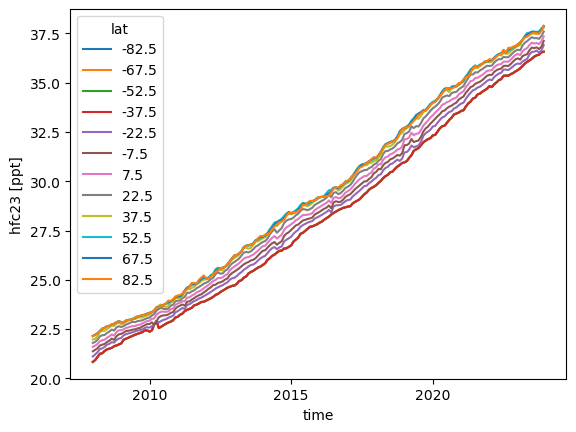

In [11]:
lon_mean = interpolated_spatial_nan_free.mean(dim="lon")
lon_mean.plot(hue="lat")  # type: ignore

### Global-, annual-mean

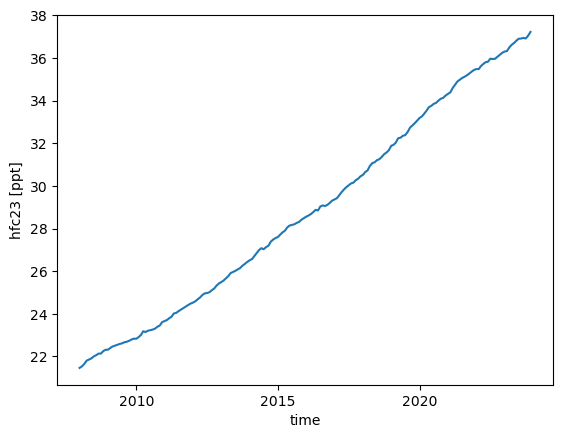

In [12]:
global_mean = local.xarray_space.calculate_global_mean_from_lon_mean(lon_mean)
global_mean.plot()  # type: ignore

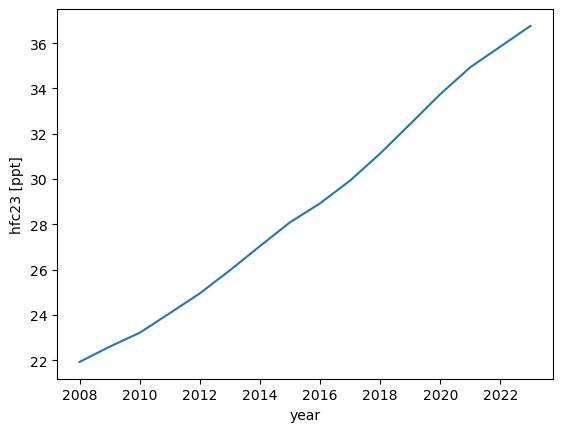

In [13]:
global_annual_mean = global_mean.groupby("time.year").mean()
global_annual_mean.plot()  # type: ignore

### Latitudinal gradient

In [14]:
(
    lat_residuals_annual_mean,
    lat_gradient_full_eofs_pcs,
) = local.latitudinal_gradient.calculate_eofs_pcs(lon_mean, global_mean)
lat_gradient_full_eofs_pcs

<xarray.Dataset> Size: 3kB
Dimensions:               (lat: 12, eof: 12, year: 16)
Coordinates:
  * lat                   (lat) float64 96B -82.5 -67.5 -52.5 ... 52.5 67.5 82.5
  * eof                   (eof) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
  * year                  (year) int64 128B 2008 2009 2010 ... 2021 2022 2023
Data variables:
    eofs                  (lat, eof) float64 1kB [ppt] 0.342 ... -5.923e-05
    principal-components  (year, eof) float64 2kB [] -1.723 ... 8.745e-19

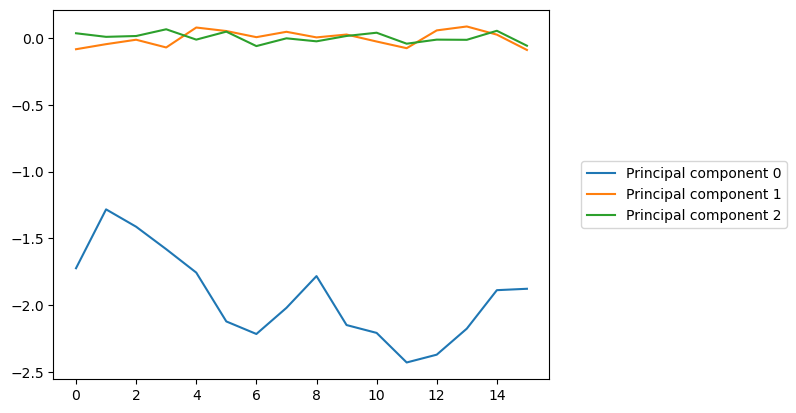

In [15]:
fig, ax = plt.subplots()
n_eofs_to_show = 3

for i in range(n_eofs_to_show):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).data.m,
        label=f"Principal component {i}",
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

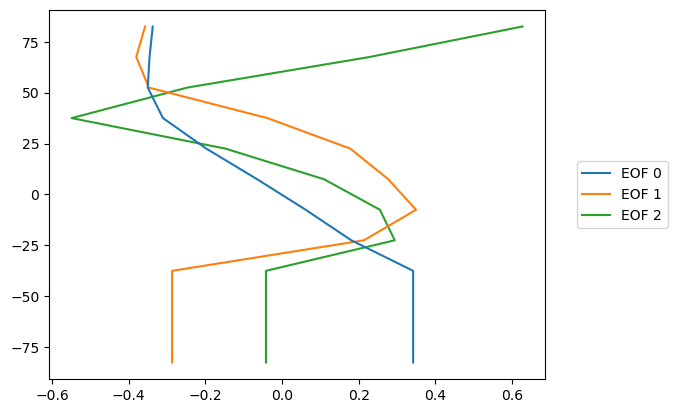

In [16]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["eofs"].sel(eof=i).data.m,
        lat_gradient_full_eofs_pcs["lat"].data,
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

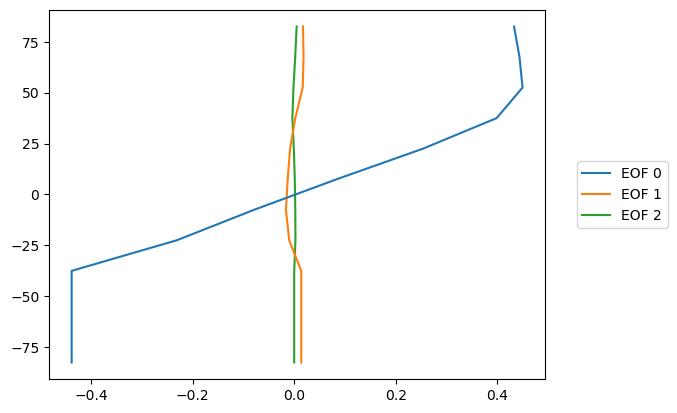

In [17]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).isel(year=1)
        @ lat_gradient_full_eofs_pcs["eofs"].sel(eof=i),
        lat_gradient_full_eofs_pcs["lat"],
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

In [18]:
lat_gradient_eofs_pcs = lat_gradient_full_eofs_pcs.sel(eof=range(config_step.lat_gradient_n_eofs_to_use))
lat_gradient_eofs_pcs

Magnitude,[[0.3419892917364612] [0.34198929173646136] [0.34198929173646125] [0.34198929173646136] [0.1806727954720925] [0.06161733706282313] [-0.06514541601090197] [-0.1974669162320733] [-0.3105721050211765] [-0.3503668332811985] [-0.3457097508171714] [-0.3372975715531777]]
Units,ppt
Magnitude,[[-1.7228316053639077] [-1.282763115803436] [-1.4125887287500591] [-1.580500383618629] [-1.7555407870227475] [-2.120722350103112] [-2.2145465245988305] [-2.0191227731580565] [-1.781603292593762] [-2.147675272434861] [-2.206395699033327] [-2.427525149355261] [-2.3691156400471503] [-2.1744980861840024] [-1.886885375802639] [-1.8764711854335674]]
Units,dimensionless


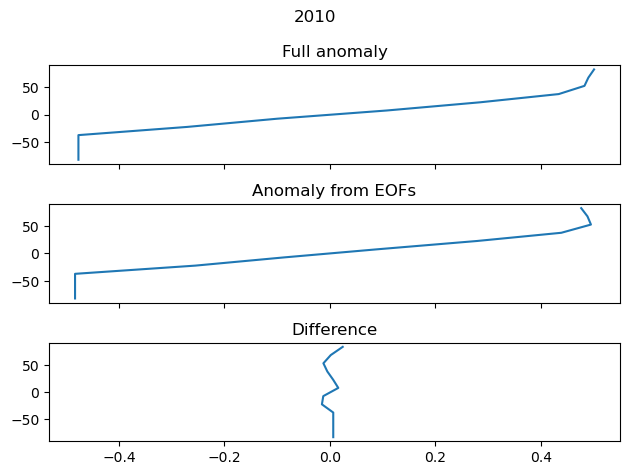

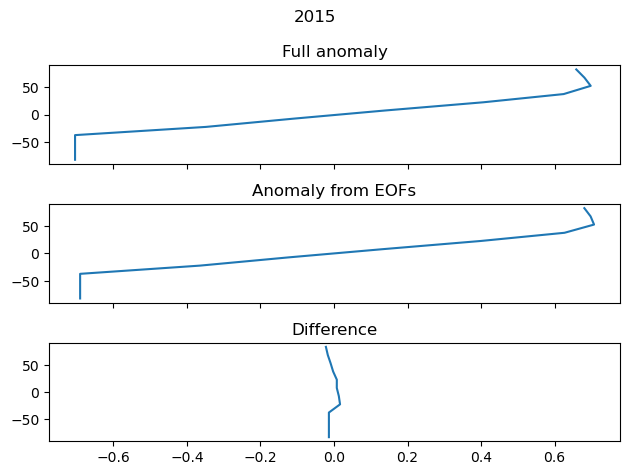

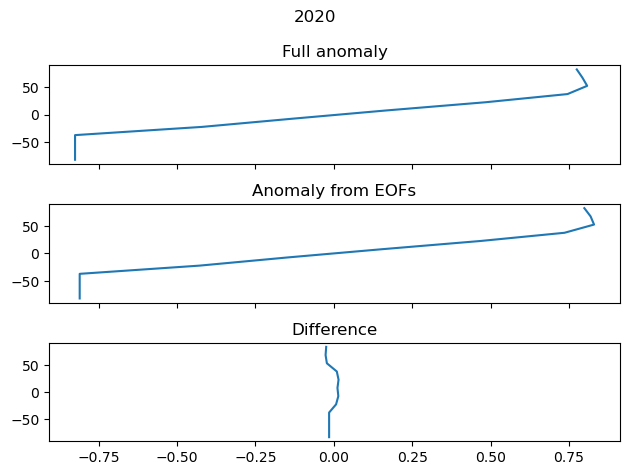

In [19]:
latitudinal_anomaly_from_eofs = lat_gradient_eofs_pcs["principal-components"] @ lat_gradient_eofs_pcs["eofs"]

for year in latitudinal_anomaly_from_eofs["year"]:
    if year % 5:
        continue

    fig, axes = plt.subplots(nrows=3, sharex=True, sharey=True)
    if isinstance(axes, matplotlib.axes.Axes):
        raise TypeError(type(axes))

    selected = lat_residuals_annual_mean.sel(year=year)
    axes[0].plot(selected.data.m, lat_residuals_annual_mean.lat)
    axes[0].set_title("Full anomaly")

    selected_eofs = latitudinal_anomaly_from_eofs.sel(year=year)
    axes[1].plot(selected_eofs.data.m, latitudinal_anomaly_from_eofs.lat)
    axes[1].set_title("Anomaly from EOFs")

    axes[2].plot(selected.data.m - selected_eofs.data.m, lat_residuals_annual_mean.lat)
    axes[2].set_title("Difference")

    axes[0].set_ylim([-90, 90])

    plt.suptitle(str(int(year)))
    plt.tight_layout()
    plt.show()

### Seasonality

In [20]:
(
    seasonality,
    relative_seasonality,
    lon_mean_ym_monthly_anomalies,
) = local.seasonality.calculate_seasonality(
    lon_mean=lon_mean,
    global_mean=global_mean,
)

/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore
/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/.pixi/envs/all-dev/lib/python3.11/importlib/__init__.py:126: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  return _bootstrap._gcd_import(name[level:], package, level)


Calculating output values:   0%|                                                                                                                                                                                      | 0/192 [00:00<?, ?it/s]

Calculating output values: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 192/192 [00:00<00:00, 9786.56it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/192 [00:00<?, ?it/s]

...

Calculating output values:   0%|                                                                                                                                                                                      | 0/192 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 192/192 [00:00<00:00, 19947.64it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/192 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 192/192 [00:00<00:00, 19750.97it/s]

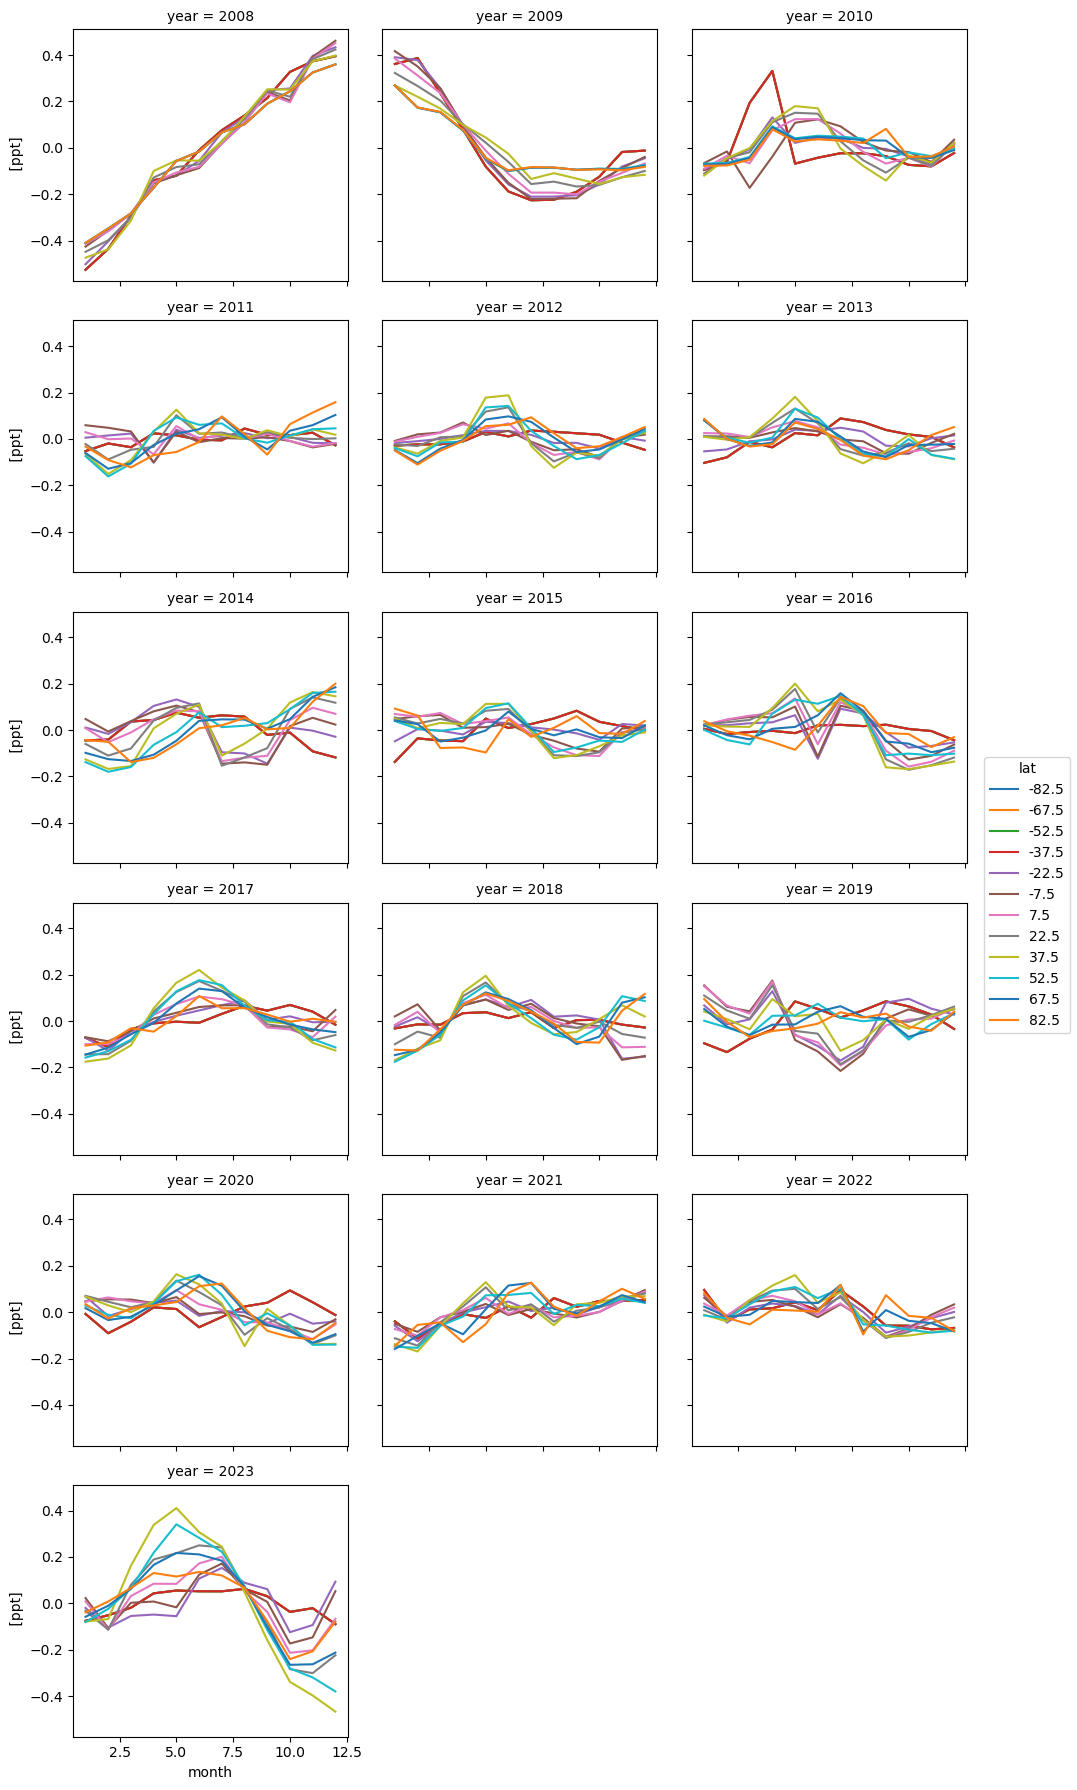

In [21]:
lon_mean_ym_monthly_anomalies.plot.line(hue="lat", col="year", col_wrap=3)

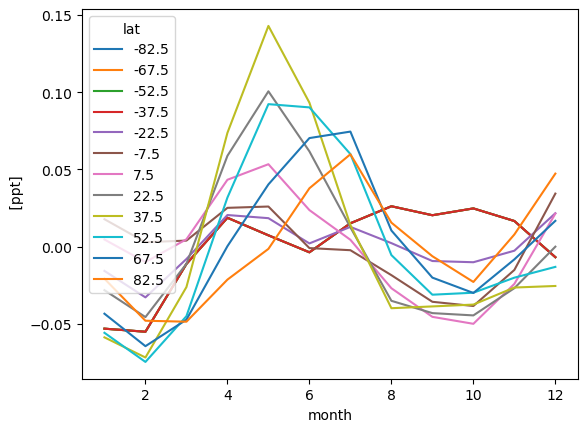

In [22]:
seasonality.plot.line(hue="lat")

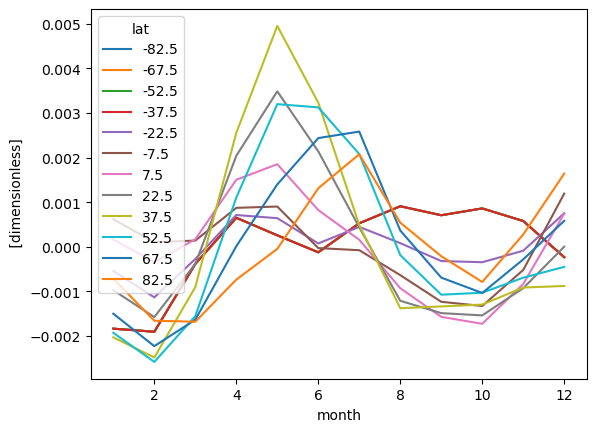

In [23]:
relative_seasonality.plot.line(hue="lat")

### Save

In [24]:
config_step.observational_network_global_annual_mean_file.parent.mkdir(exist_ok=True, parents=True)
global_annual_mean.pint.dequantify().to_netcdf(config_step.observational_network_global_annual_mean_file)
global_annual_mean

Magnitude,[21.92577167592212 22.59730643342125 23.213021622589835 24.077146205091072 24.95148585630078 25.969905635259426 27.039148518225478 28.090158412386334 28.929843186736303 29.933097553913388 31.129501486607797 32.43248594392205 33.75102340932314 34.94034216689851 35.85251666401702 36.76300223891555]
Units,ppt


In [25]:
config_step.observational_network_latitudinal_gradient_eofs_file.parent.mkdir(exist_ok=True, parents=True)
lat_gradient_eofs_pcs.pint.dequantify().to_netcdf(
    config_step.observational_network_latitudinal_gradient_eofs_file
)
lat_gradient_eofs_pcs

Magnitude,[[0.3419892917364612] [0.34198929173646136] [0.34198929173646125] [0.34198929173646136] [0.1806727954720925] [0.06161733706282313] [-0.06514541601090197] [-0.1974669162320733] [-0.3105721050211765] [-0.3503668332811985] [-0.3457097508171714] [-0.3372975715531777]]
Units,ppt
Magnitude,[[-1.7228316053639077] [-1.282763115803436] [-1.4125887287500591] [-1.580500383618629] [-1.7555407870227475] [-2.120722350103112] [-2.2145465245988305] [-2.0191227731580565] [-1.781603292593762] [-2.147675272434861] [-2.206395699033327] [-2.427525149355261] [-2.3691156400471503] [-2.1744980861840024] [-1.886885375802639] [-1.8764711854335674]]
Units,dimensionless


In [26]:
# Use relative seasonality
config_step.observational_network_seasonality_file.parent.mkdir(exist_ok=True, parents=True)
relative_seasonality.pint.dequantify().to_netcdf(config_step.observational_network_seasonality_file)
relative_seasonality

Magnitude,[[-0.0018361910253098066 -0.0019050595151943448 -0.00038508648290653646 0.0006499712017889791 0.00025624335926696635 -0.00012396336502027165 0.0005261404814686531 0.0009081024485294003 0.0007067542269383771 0.0008596318993173569 0.0005773102116702723 -0.0002338800726920888] [-0.0018361910253098066 -0.0019050595151943448 -0.00038508648290653646 0.0006499712017889791 0.00025624335926696635 -0.00012396336502027165 0.0005261404814686531 0.0009081024485294003 0.0007067542269383771 0.0008596318993173569 0.0005773102116702723 -0.0002338800726920888] [-0.0018361910253098066 -0.0019050595151943448 -0.00038508648290653646 0.0006499712017889791 0.00025624335926696635 -0.00012396336502027165 0.0005261404814686531 0.0009081024485294003 0.0007067542269383771 0.0008596318993173569 0.0005773102116702723 -0.0002338800726920888] [-0.0018361910253098066 -0.0019050595151943448 -0.00038508648290653646 0.0006499712017889791 0.00025624335926695865 -0.00012396336502027165 0.0005261404814686454 0.0009081024485294003 0.0007067542269383771 0.0008596318993173569 0.0005773102116702723 -0.0002338800726920888] [-0.0005410533997844424 -0.0011345497266849376 -0.00027433724621066133 0.0007114698879909216 0.0006408880964986323 7.501477167289018e-05 0.0004452855181344443 8.131408113125607e-05 -0.000319848901658039 -0.00034692685676510776 -8.84983684268477e-05 0.0007512202816691091] [0.0006177510041525538 0.00010244185512651505 0.00013835476546141773 0.0008724610462756254 0.0009017388778666667 -2.9722992991641415e-05 -7.72331871566227e-05 -0.0006365138720378642 -0.0012337096346347028 -0.0013280206850301152 -0.0005195465285235594 0.001191974899214118] [0.0001623857913523225 -0.000343322392996445 0.0001679139749051106 0.0015019605224489624 0.0018503691168407224 0.0008218571840728555 0.0001563036479209352 -0.000929667764327866 -0.001571248256607149 -0.0017272385282092134 -0.0008324204681767051 0.0007430765743130989] [-0.0009733418487844986 -0.0015766224294307735 -0.0003825805562547141 0.002038489968400419 0.003484595460480115 0.0021386161812038695 0.0004350285648207339 -0.0012117287188142007 -0.0014875714756752872 -0.0015387968763176877 -0.0009281556894157731 2.0285382712658266e-06] [-0.0020307756680639443 -0.0024822677139249264 -0.0009034506758172397 0.0025535829888979475 0.004950551949304878 0.003230015382487374 0.00048653413178516123 -0.00137754978789755 -0.0013373851997020441 -0.001296096331465259 -0.0009140246756044479 -0.0008791845400409313] [-0.0019287753775350993 -0.002581566717031118 -0.0015556357778968757 0.001102596387947961 0.0031969246855339476 0.0031242880483525587 0.0020776152920738275 -0.00018681043285359223 -0.0010745818796548436 -0.0010301878489097159 -0.0006929507231656042 -0.0004509607487732801] [-0.0015006864349808664 -0.002228526102915689 -0.0016345326755343543 1.2479887435297252e-05 0.0013976979403446939 0.0024364112120101905 0.002581742197082529 0.0003645715127261481 -0.000691768019968849 -0.0010357772621128337 -0.0002828538197930815 0.0005812047200704366] [-0.0007169224047282771 -0.0016581700056166947 -0.0016799442183653948 -0.0007369333791490392 -4.751456524281073e-05 0.001311014967686103 0.0020735908735504643 0.0005405559700608637 -0.0002120274934079454 -0.0007889288976920933 0.00027545855592574534 0.0016397902585296134]]
Units,dimensionless
